# Peripheral Strategy Backtest

This notebook tests the following specific signal:
- **Long** the peripheral stocks when the central portfolio's lagged return is positive.
- **Short** the peripheral stocks when the central portfolio's lagged return is negative.

The central and peripheral portfolios are created by stacking all out-of-sample years into one continuous series for each estimation window $k$ ($k=1$ and $k=10$). We then report the Annualized Return and Sharpe Ratio of this signal.

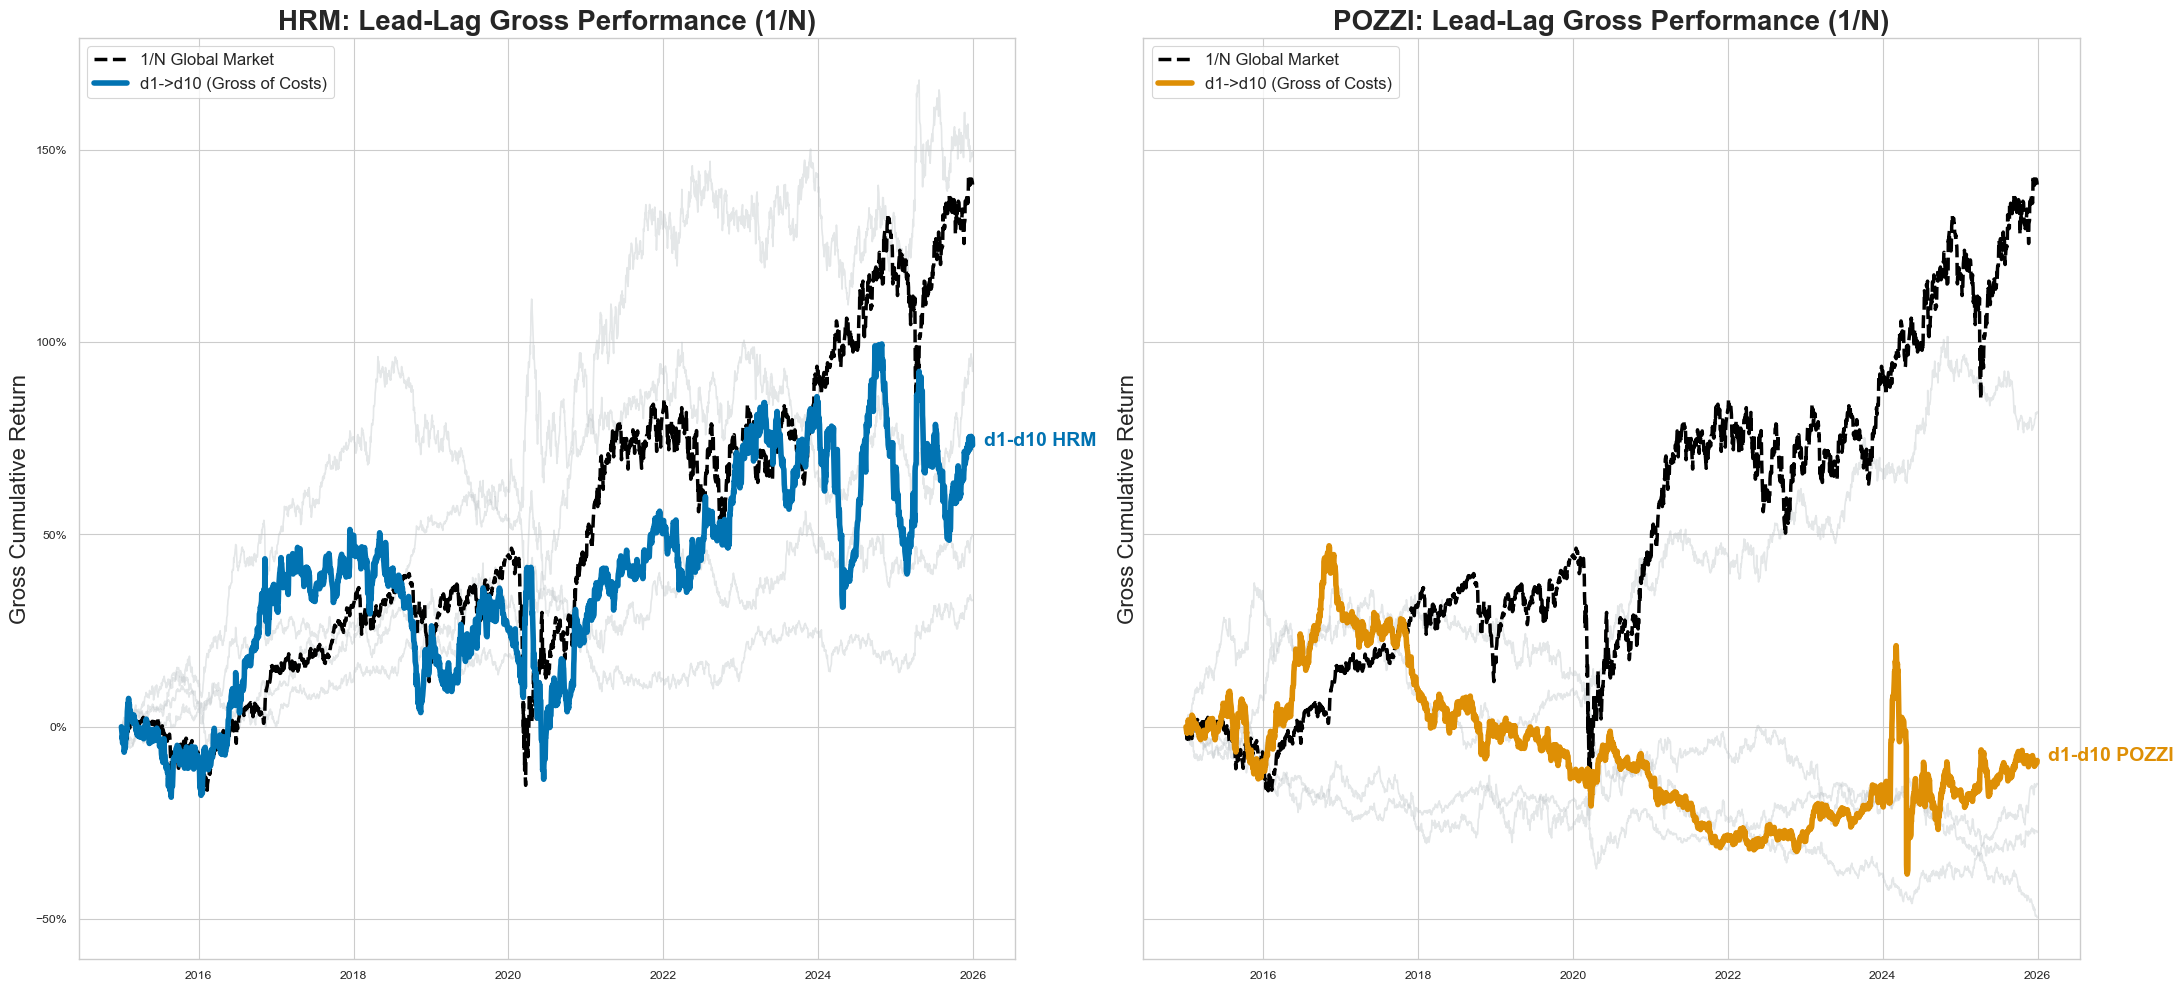

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO ---
years = range(2014, 2025)
k = 5
metrics = ["hrm", "pozzi"]
decile_pairs = [(i, 11 - i) for i in range(1, 6)] 

# 1. Carregamento do Universo Total
df_ret_full = pd.read_parquet("../../data/02_clean/returns_30_years.parquet")
df_ret_full = df_ret_full[df_ret_full.index >= pd.Timestamp(2015, 1, 1)]

# Benchmark 1/N Global (Média simples de todos os ativos disponíveis)
market_benchmark_global = np.log1p(df_ret_full).mean(axis=1)

results_strat = {m: {f"d{p}_d{c}": [] for p, c in decile_pairs} for m in metrics}

# --- LOOP DE BACKTEST (OUT-OF-SAMPLE) ---
for year in years:
    test_year = year + 1
    df_ret_oos = df_ret_full[df_ret_full.index.year == test_year]
    
    if df_ret_oos.empty:
        continue

    for metric in metrics:
        for c_idx, p_idx in decile_pairs:
            try:
                # Identificação dos decis formados no ano de treino
                c_label = f"decil_{c_idx}_{year}_{metric}"
                p_label = f"decil_{p_idx}_{year}_{metric}"
                
                cols_c = pd.read_parquet(f"../../data/06_portfolios/{c_label}.parquet").columns
                cols_p = pd.read_parquet(f"../../data/06_portfolios/{p_label}.parquet").columns
                
                # Sincronização com o que é negociável no período OOS
                valid_c = cols_c.intersection(df_ret_oos.columns)
                valid_p = cols_p.intersection(df_ret_oos.columns)

                # 2. CÁLCULO 1/N (Média Simples)
                ret_c = np.log1p(df_ret_oos[valid_c]).mean(axis=1)
                ret_p = np.log1p(df_ret_oos[valid_p]).mean(axis=1)

                # --- ESTRATÉGIA LEAD-LAG BRUTA (GROSS RETURNS) ---
                # Sinal do líder (Central)
                signal = np.sign(ret_c.shift(1)).fillna(0)
                
                # Spread PMC: Peripheral Minus Central (Neutralizando Beta)
                # Sem custos de transação (Gross of Fees)
                strat_ret = signal * (ret_p - ret_c)
                
                results_strat[metric][f"d{c_idx}_d{p_idx}"].append(strat_ret)
                
            except FileNotFoundError:
                continue

# --- CONSOLIDAÇÃO ---
final_results = {}
for m in metrics:
    for pair_key in results_strat[m]:
        if results_strat[m][pair_key]:
            final_results[f"{m}_{pair_key}"] = pd.concat(results_strat[m][pair_key])

# --- VISUALIZAÇÃO ---
sns.set_theme(style="whitegrid", context="paper")
fig, axes = plt.subplots(1, 2, figsize=(22, 10), sharey=True)
palette = sns.color_palette("colorblind")

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # 1/N Market Benchmark (Global)
    common_idx = final_results[f"{metric}_d1_d10"].index
    mkt_plot = market_benchmark_global.loc[common_idx]
    cum_market = np.exp(mkt_plot.cumsum()) - 1
    ax.plot(cum_market.index, cum_market, color='black', lw=2.5, ls='--', label='1/N Global Market')

    # Pares Intermediários (Visual 'Faded')
    for c_idx, p_idx in decile_pairs[1:]:
        pair_key = f"{metric}_d{c_idx}_d{p_idx}"
        if pair_key in final_results:
            rets = final_results[pair_key]
            cum_rets = np.exp(rets.cumsum()) - 1
            ax.plot(cum_rets.index, cum_rets, color='#BDC3C7', lw=1.2, alpha=0.4, zorder=1)

    # Par Principal (d1 Central vs d10 Peripheral)
    pair_main = f"{metric}_d1_d10"
    if pair_main in final_results:
        rets = final_results[pair_main]
        cum_rets = np.exp(rets.cumsum()) - 1
        ax.plot(cum_rets.index, cum_rets, color=palette[idx], lw=4, label='d1->d10 (Gross of Costs)', zorder=5)
        
        # Labeling
        ax.annotate(f"d1-d10 {metric.upper()}", xy=(cum_rets.index[-1], cum_rets.iloc[-1]), 
                    xytext=(8, 0), textcoords='offset points', fontsize=14, fontweight='bold', color=palette[idx])

    ax.set_title(f"{metric.upper()}: Lead-Lag Gross Performance (1/N)", fontsize=20, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylabel("Gross Cumulative Return", fontsize=16)
    ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig("../../figures/strategy_gross_1n.png", dpi=300)
plt.show()

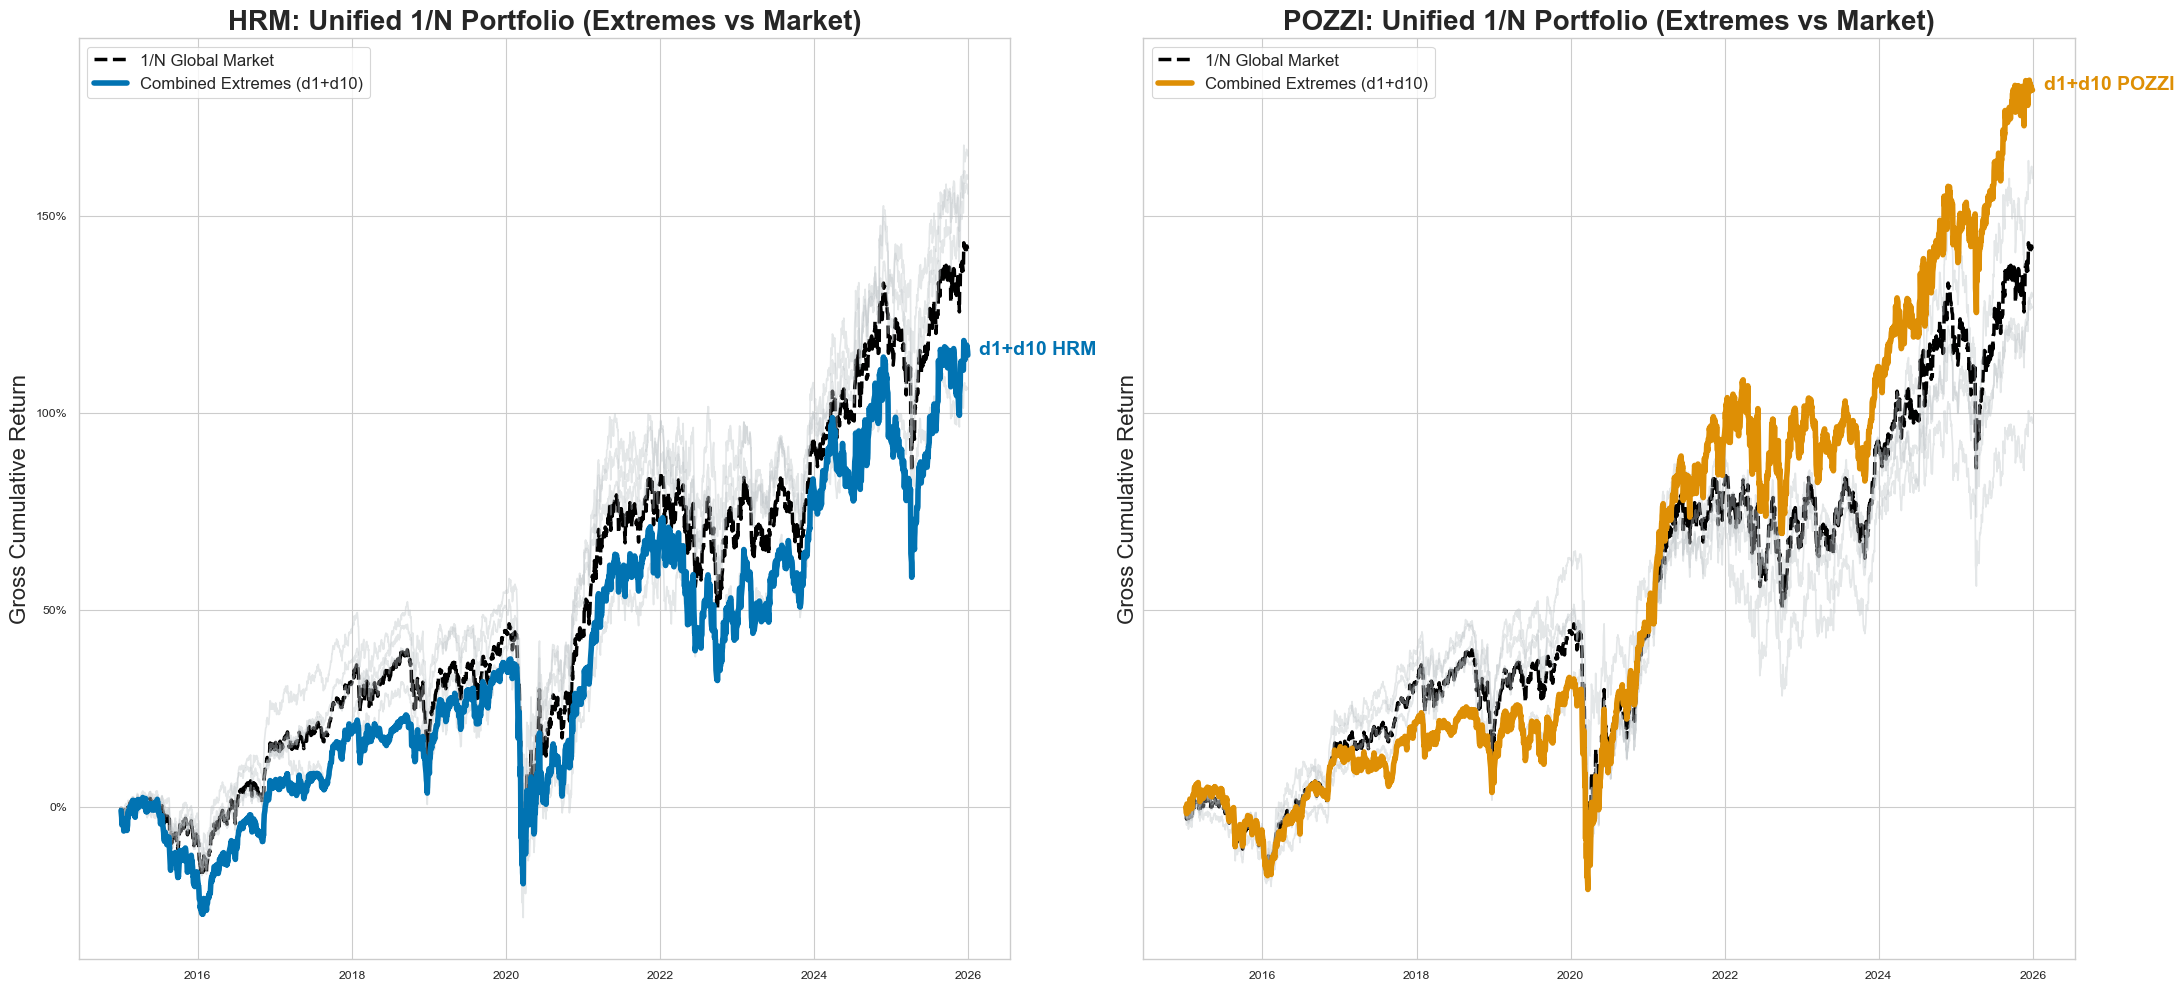

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO ---
years = range(2014, 2025)
k = 5
metrics = ["hrm", "pozzi"]
# Pares simétricos: vamos unir d1+d10, d2+d9, etc.
decile_pairs = [(i, 11 - i) for i in range(1, 6)] 

# 1. Carregamento do Universo Total para o Benchmark
df_ret_full = pd.read_parquet("../../data/02_clean/returns_30_years.parquet")
df_ret_full = df_ret_full[df_ret_full.index >= pd.Timestamp(2015, 1, 1)]

# Benchmark Global 1/N (Média de TODOS os ativos do mercado)
market_benchmark_global = np.log1p(df_ret_full).mean(axis=1)

results_strat = {m: {f"d{p}_d{c}": [] for p, c in decile_pairs} for m in metrics}

# --- LOOP DE BACKTEST (OUT-OF-SAMPLE) ---
for year in years:
    test_year = year + 1
    df_ret_oos = df_ret_full[df_ret_full.index.year == test_year]
    
    if df_ret_oos.empty:
        continue

    for metric in metrics:
        for idx_1, idx_2 in decile_pairs:
            try:
                # Carregar tickers de ambos os decis do par
                label_1 = f"decil_{idx_1}_{year}_{metric}"
                label_2 = f"decil_{idx_2}_{year}_{metric}"
                
                cols_1 = pd.read_parquet(f"../../data/06_portfolios/{label_1}.parquet").columns
                cols_2 = pd.read_parquet(f"../../data/06_portfolios/{label_2}.parquet").columns
                
                # UNIFICAR OS ATIVOS (Juntar Central + Peripheral)
                # O set garante que se um ativo estiver em ambos (raro), não seja duplicado
                combined_tickers = list(set(cols_1) | set(cols_2))
                
                # Sincronização com ativos disponíveis no ano de teste
                valid_tickers = [t for t in combined_tickers if t in df_ret_oos.columns]

                if not valid_tickers:
                    continue

                # --- CÁLCULO DO PORTFÓLIO UNIFICADO 1/N ---
                # Pegamos todos os ativos do par e tiramos a média simples (1/N)
                # Sem sinais, sem long-short. Apenas o retorno do conjunto.
                ret_combined_1n = np.log1p(df_ret_oos[valid_tickers]).mean(axis=1)
                
                results_strat[metric][f"d{idx_1}_d{idx_2}"].append(ret_combined_1n)
                
            except FileNotFoundError:
                continue

# --- CONSOLIDAÇÃO ---
final_results = {}
for m in metrics:
    for pair_key in results_strat[m]:
        if results_strat[m][pair_key]:
            final_results[f"{m}_{pair_key}"] = pd.concat(results_strat[m][pair_key])

# --- VISUALIZAÇÃO ---
sns.set_theme(style="whitegrid", context="paper")
fig, axes = plt.subplots(1, 2, figsize=(22, 10), sharey=True)
palette = sns.color_palette("colorblind")

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # 1. Benchmark 1/N Market (Todas as ações)
    common_idx = final_results[f"{metric}_d1_d10"].index
    mkt_plot = market_benchmark_global.loc[common_idx]
    cum_market = np.exp(mkt_plot.cumsum()) - 1
    ax.plot(cum_market.index, cum_market, color='black', lw=2.5, ls='--', label='1/N Global Market')

    # 2. Portfólios Unificados Intermediários (d2+d9, etc.)
    for idx_1, idx_2 in decile_pairs[1:]:
        pair_key = f"{metric}_d{idx_1}_d{idx_2}"
        if pair_key in final_results:
            rets = final_results[pair_key]
            cum_rets = np.exp(rets.cumsum()) - 1
            ax.plot(cum_rets.index, cum_rets, color='#BDC3C7', lw=1.2, alpha=0.4)

    # 3. Portfólio Unificado de Destaque (d1 + d10)
    pair_main = f"{metric}_d1_d10"
    if pair_main in final_results:
        rets = final_results[pair_main]
        cum_rets = np.exp(rets.cumsum()) - 1
        ax.plot(cum_rets.index, cum_rets, color=palette[idx], lw=4, label='Combined Extremes (d1+d10)')
        
        ax.annotate(f"d1+d10 {metric.upper()}", xy=(cum_rets.index[-1], cum_rets.iloc[-1]), 
                    xytext=(8, 0), textcoords='offset points', fontsize=14, fontweight='bold', color=palette[idx])

    ax.set_title(f"{metric.upper()}: Unified 1/N Portfolio (Extremes vs Market)", fontsize=20, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylabel("Gross Cumulative Return", fontsize=16)
    ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

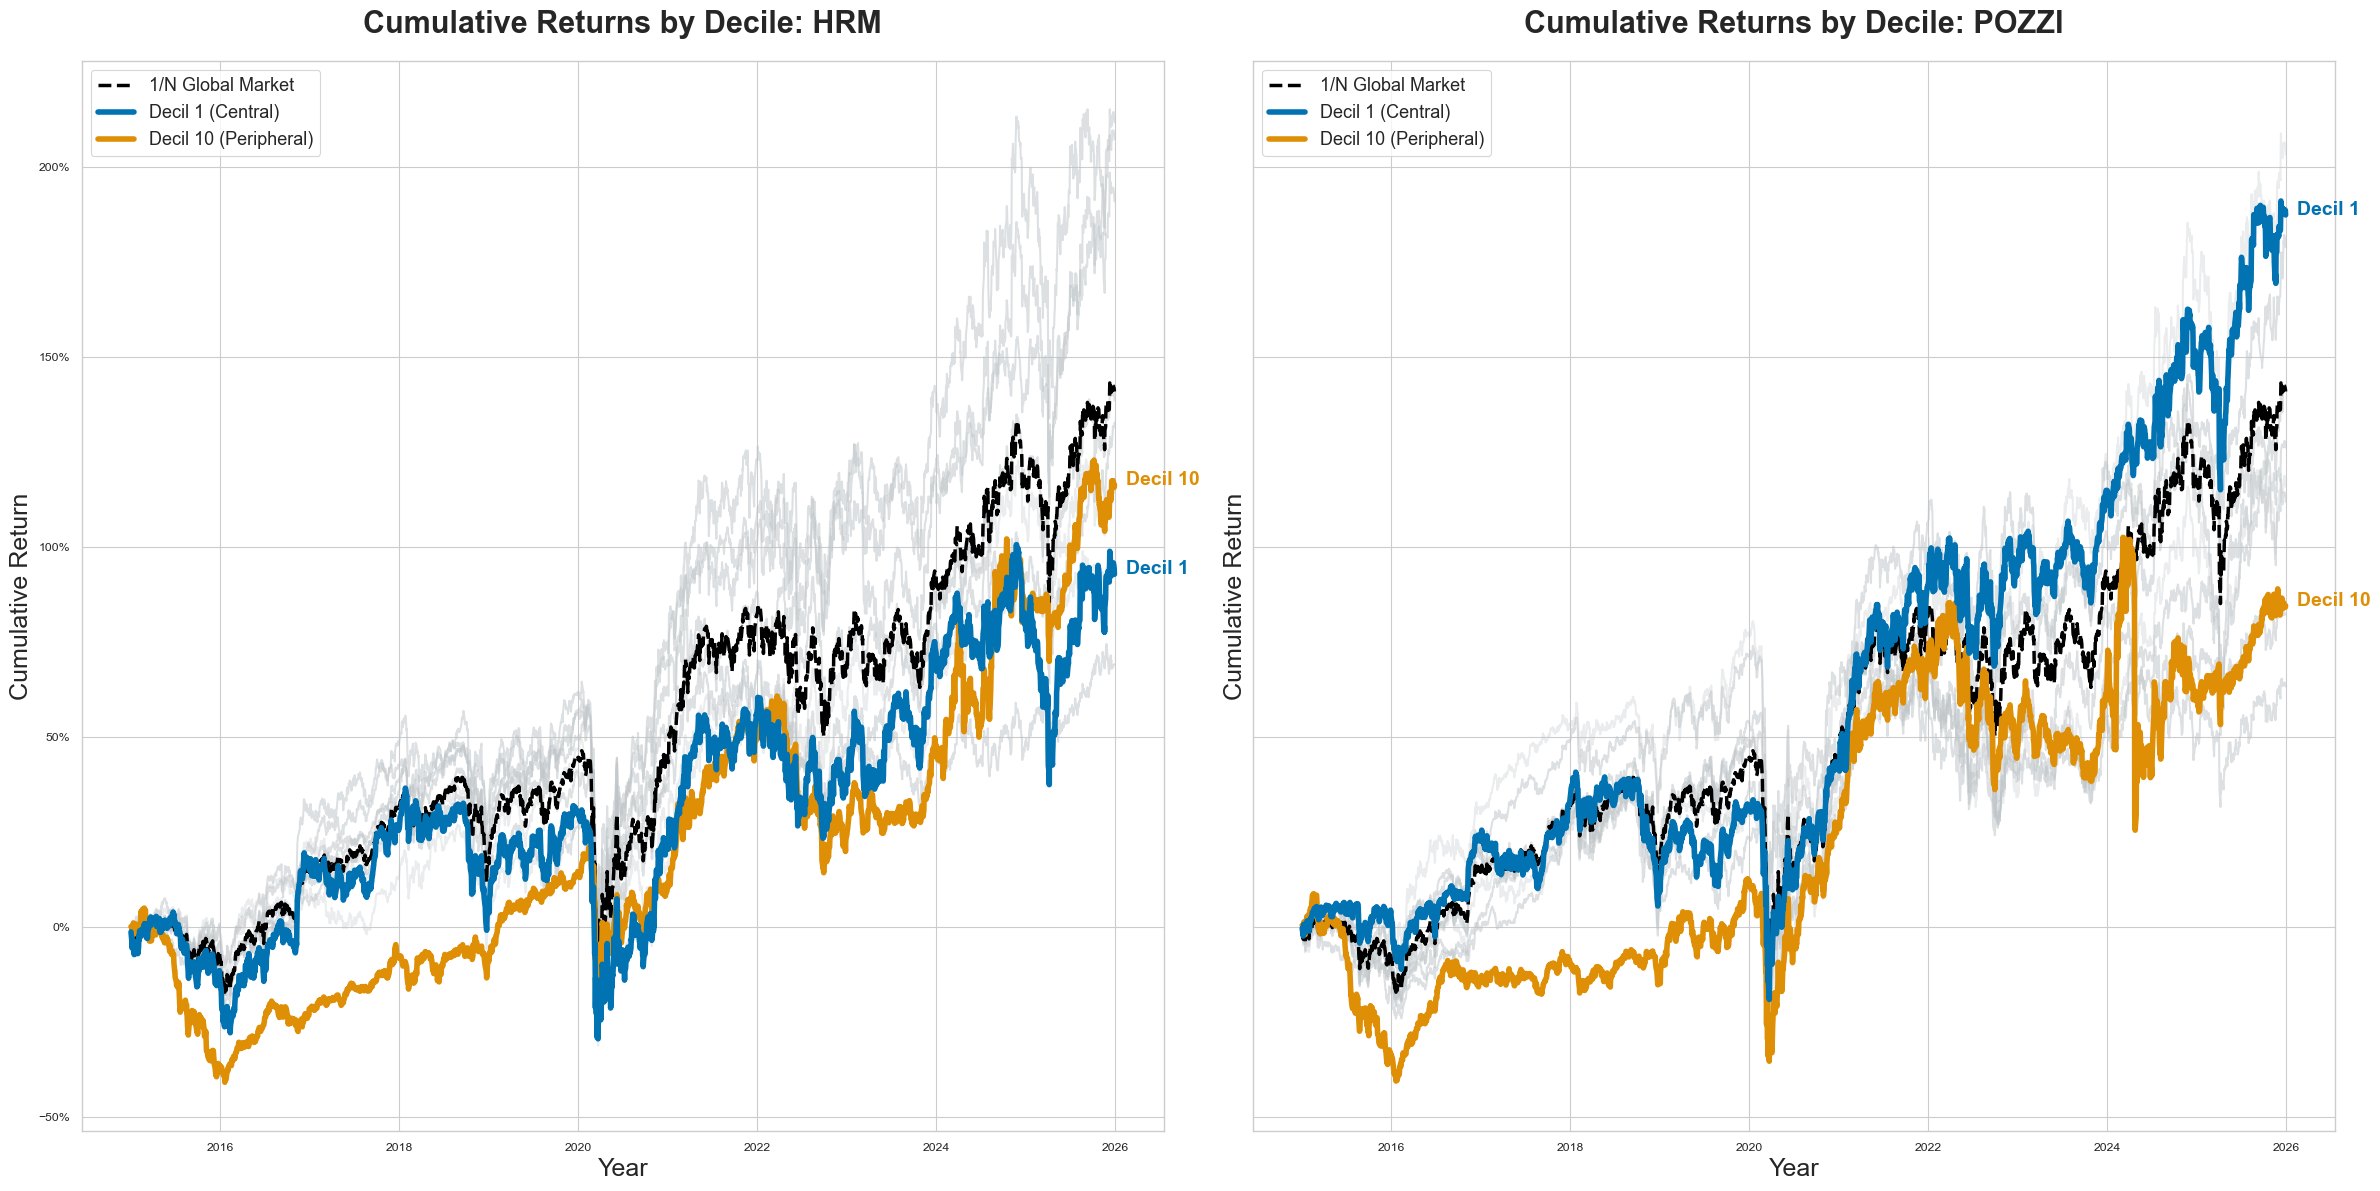

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO ---
years = range(2014, 2025)
metrics = ["hrm", "pozzi"]
deciles = [f"decil_{i}" for i in range(1, 11)] # d1 até d10

# 1. Carregamento do Universo Total para Benchmark
df_ret_full = pd.read_parquet("../../data/02_clean/returns_30_years.parquet")
df_ret_full = df_ret_full[df_ret_full.index >= pd.Timestamp(2015, 1, 1)]
market_benchmark_global = np.log1p(df_ret_full).mean(axis=1)

# Dicionário para armazenar retornos individuais de cada decil
# {metrica: {decil_n: [lista_de_series_anuais]}}
decile_results = {m: {d: [] for d in deciles} for m in metrics}

# --- LOOP DE BACKTEST (OUT-OF-SAMPLE) ---
for year in years:
    test_year = year + 1
    df_ret_oos = df_ret_full[df_ret_full.index.year == test_year]
    
    if df_ret_oos.empty:
        continue

    for metric in metrics:
        for decil in deciles:
            try:
                # Carregar tickers do decil específico formado no ano de treino
                label = f"{decil}_{year}_{metric}"
                cols = pd.read_parquet(f"../../data/06_portfolios/{label}.parquet").columns
                
                # Sincronização com o mercado no ano OOS
                valid_cols = cols.intersection(df_ret_oos.columns)

                if len(valid_cols) == 0:
                    continue

                # --- CÁLCULO 1/N DO DECIL ---
                ret_1n = np.log1p(df_ret_oos[valid_cols]).mean(axis=1)
                decile_results[metric][decil].append(ret_1n)
                
            except FileNotFoundError:
                continue

# --- CONSOLIDAÇÃO ---
final_deciles = {m: {} for m in metrics}
for m in metrics:
    for d in deciles:
        if decile_results[m][d]:
            final_deciles[m][d] = pd.concat(decile_results[m][d])

# --- VISUALIZAÇÃO LADO A LADO ---
sns.set_theme(style="whitegrid", context="paper")
fig, axes = plt.subplots(1, 2, figsize=(24, 12), sharey=True)
palette = sns.color_palette("colorblind")

# Cores específicas para os extremos
color_d1 = palette[0]  # Azul (Central)
color_d10 = palette[1] # Laranja (Periférico)

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    m_data = final_deciles[metric]
    
    # 1. Plot do Benchmark Global (Preto Tracejado)
    common_idx = m_data["decil_1"].index
    mkt_plot = market_benchmark_global.loc[common_idx]
    cum_market = np.exp(mkt_plot.cumsum()) - 1
    ax.plot(cum_market.index, cum_market, color='black', lw=2.5, ls='--', label='1/N Global Market', zorder=2)

    # 2. Plot dos Decis Intermediários (Degradê de Cinza)
    for i in range(2, 10): # decil_2 ao decil_9
        d_label = f"decil_{i}"
        if d_label in m_data:
            rets = m_data[d_label]
            cum_rets = np.exp(rets.cumsum()) - 1
            # O alfa diminui conforme se aproxima do centro (d5/d6)
            alpha_val = 0.3 if i in [5, 6] else 0.5
            ax.plot(cum_rets.index, cum_rets, color='#BDC3C7', lw=1.5, alpha=alpha_val, zorder=1)

    # 3. Plot dos Extremos (Destaque)
    # Decil 1 - Central
    if "decil_1" in m_data:
        rets_d1 = m_data["decil_1"]
        cum_d1 = np.exp(rets_d1.cumsum()) - 1
        ax.plot(cum_d1.index, cum_d1, color=color_d1, lw=4, label='Decil 1 (Central)', zorder=5)
        ax.annotate("Decil 1", xy=(cum_d1.index[-1], cum_d1.iloc[-1]), xytext=(8, 0),
                    textcoords='offset points', fontsize=14, fontweight='bold', color=color_d1)

    # Decil 10 - Periférico
    if "decil_10" in m_data:
        rets_d10 = m_data["decil_10"]
        cum_d10 = np.exp(rets_d10.cumsum()) - 1
        ax.plot(cum_d10.index, cum_d10, color=color_d10, lw=4, label='Decil 10 (Peripheral)', zorder=4)
        ax.annotate("Decil 10", xy=(cum_d10.index[-1], cum_d10.iloc[-1]), xytext=(8, 0),
                    textcoords='offset points', fontsize=14, fontweight='bold', color=color_d10)

    # Formatação
    ax.set_title(f"Cumulative Returns by Decile: {metric.upper()}", fontsize=22, fontweight='bold', pad=20)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylabel("Cumulative Return", fontsize=18)
    ax.set_xlabel("Year", fontsize=18)
    
    # Legenda apenas com o essencial
    ax.legend(loc='upper left', fontsize=13, frameon=True)

plt.tight_layout()
plt.savefig("../../figures/cumulative_returns_deciles_comparison.png", dpi=300)
plt.show()

--- Strategy Performance Comparison ---
                                     Ann. Return (%)  Ann. Volatility (%)  \
Strategy                                                                    
Lead-Lag Graph (k=1)                           -1.57                18.37   
Lead-Lag Graph (k=10)                          12.02                23.89   
Active Size Strategy (Large->Small)            24.74                21.02   
1/N Market Benchmark                          -16.57                23.30   

                                     Sharpe Ratio  Max Drawdown (%)  
Strategy                                                             
Lead-Lag Graph (k=1)                        -0.09            -34.49  
Lead-Lag Graph (k=10)                        0.50            -30.75  
Active Size Strategy (Large->Small)          1.18            -19.99  
1/N Market Benchmark                        -0.71            -57.96  


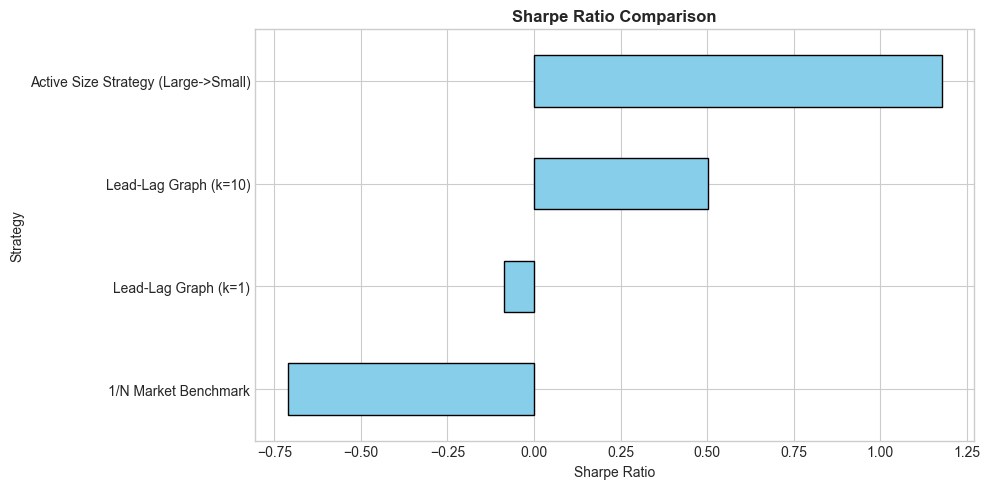

In [13]:
import pandas as pd
import numpy as np

# 1. Setup constants
TRADING_DAYS = 252
RISK_FREE_RATE = 0.0  # Adjust if you have a specific benchmark rate

stats_list = []

for name, rets in strategy_returns_dict.items():
    # We use simple arithmetic returns for standard financial metrics 
    # but since you've stored log returns, we use the following:
    
    # Annualized Return (Geometric mean approach for log returns)
    ann_return = rets.mean() * TRADING_DAYS
    
    # Annualized Volatility
    ann_vol = rets.std() * np.sqrt(TRADING_DAYS)
    
    # Sharpe Ratio
    sharpe = (ann_return - RISK_FREE_RATE) / ann_vol if ann_vol != 0 else np.nan
    
    # Optional: Max Drawdown (adds great context to the 60% gain)
    cum_rets = rets.cumsum() # in log space
    wealth_index = np.exp(cum_rets)
    previous_peaks = wealth_index.cummax()
    drawdowns = (wealth_index - previous_peaks) / previous_peaks
    max_drawdown = drawdowns.min()

    stats_list.append({
        "Strategy": name,
        "Ann. Return (%)": ann_return * 100,
        "Ann. Volatility (%)": ann_vol * 100,
        "Sharpe Ratio": sharpe,
        "Max Drawdown (%)": max_drawdown * 100
    })

# 2. Create and Format DataFrame
df_stats = pd.DataFrame(stats_list).set_index("Strategy")

# Apply styling for better readability
pd.options.display.float_format = '{:,.2f}'.format
print("--- Strategy Performance Comparison ---")
print(df_stats)

# 3. Quick Visualization of Sharpe Ratios
plt.figure(figsize=(10, 5))
df_stats['Sharpe Ratio'].sort_values().plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Sharpe Ratio Comparison', fontweight='bold')
plt.xlabel('Sharpe Ratio')
plt.tight_layout()
plt.show()